CAR PRICE PREDICTION
Oasis Infobyte Internship

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score



In [2]:
# ------ Dataset Loading -------
df=pd.read_csv("car data.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n")
print(df.head())      

Dataset Shape: (301, 9)

First 5 Rows:

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
# ---------- Data Cleaning ----------

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [4]:
# ---------- Feature Engineering ----------

# Create a new column: Car Age
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# Remove unnecessary columns
df = df.drop(columns=['Car_Name', 'Year'])

print("\nUpdated Dataset:\n")
print(df.head())


Updated Dataset:

   Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0           3.35           5.59       27000    Petrol       Dealer   
1           4.75           9.54       43000    Diesel       Dealer   
2           7.25           9.85        6900    Petrol       Dealer   
3           2.85           4.15        5200    Petrol       Dealer   
4           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       12  
1       Manual      0       13  
2       Manual      0        9  
3       Manual      0       15  
4       Manual      0       12  


In [5]:
# ---------- Convert Categorical Data ----------

# Convert text columns into numeric values and drop the first category to avoid multicollinearity
df = pd.get_dummies(df, drop_first=True)

print("\nEncoded Columns:\n")
print(df.columns)


Encoded Columns:

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')


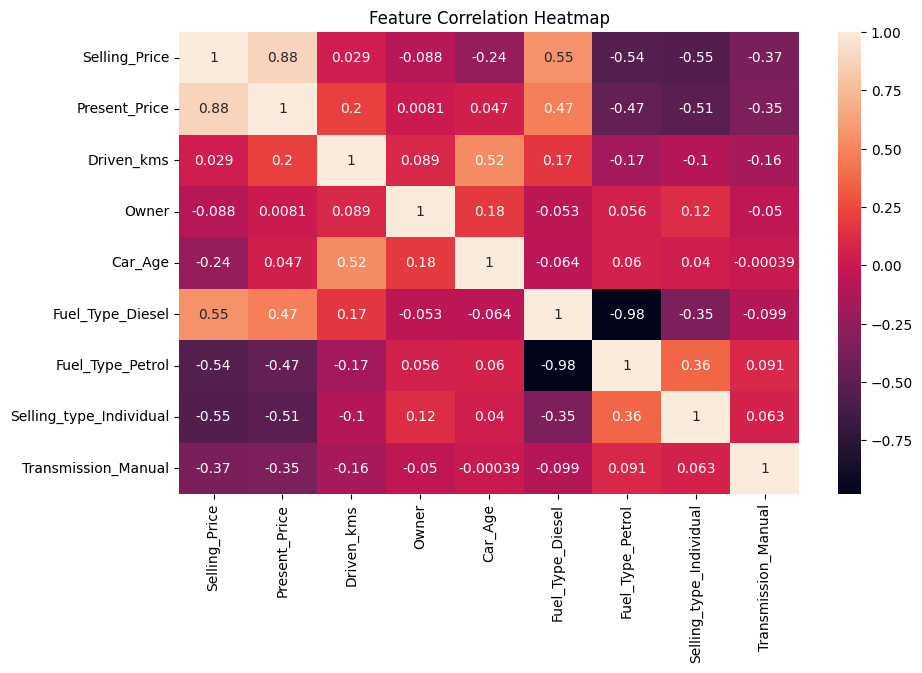

In [7]:
# ---------- Data Visualization ----------

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [8]:
# ---------- Split Data ----------

X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (240, 8)
Testing Data: (61, 8)


In [9]:
# ---------- Train Model ----------

model = LinearRegression()

# Train model
model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)

print("\nPredicted Prices:\n")
print(y_pred[:5])



Predicted Prices:

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657]


In [10]:
# ---------- Model Evaluation ----------

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))


Mean Absolute Error: 1.22
R2 Score: 0.85


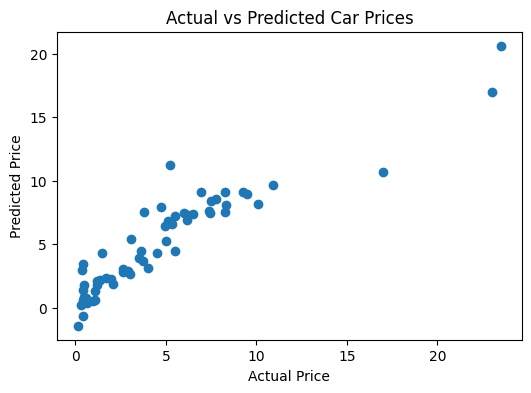

In [11]:
# ---------- Actual vs Predicted Graph ----------

plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [12]:
# ---------- Manual Prediction ----------
# Example:
# Present_Price, Driven_kms, Owner, Car_Age,
# Fuel_Type_Diesel, Fuel_Type_Petrol,
# Selling_type_Individual,
# Transmission_Manual

sample = [[5.59, 27000, 0, 12, 0, 1, 0, 1]]

predicted_price = model.predict(sample)

print("\nPredicted Car Price:",
      round(predicted_price[0], 2), "Lakhs")


Predicted Car Price: 3.94 Lakhs


c:\Users\asus\Desktop\OasisInfobyte\.venv\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


In [13]:
# ---------- Final Conclusion ----------

print("\nConclusion:")
print("The Linear Regression model successfully predicted car prices.")
print("Features like present price, fuel type, and car age affect selling price.")


Conclusion:
The Linear Regression model successfully predicted car prices.
Features like present price, fuel type, and car age affect selling price.
